##### Homework 5, Part 1: Building a pandas cheat sheet

**Use `animals.csv` to answer the following questions.** The data is small and the questions are pretty simple, so hopefully you can use this for pandas reference in the future.

> **Don't use ChatGPT for this assignment.** I know I talked about how *yes ChatGPT is great for memorizing pandas stuff* but what I want you to do instead is:
>
> 1. Try to use tab autocomplete to see what your options might be (e.g. type `df.so` then press tab)
> 2. Use shift+tab to read documentation about things (e.g. click `sort_values` then press shift+tab)
> 3. Ask in #foundations because it's just TOO QUIET in there
> 4. Chat with TAs so you can have Jasen say "WHY ARE YOU USING df PERIOD, IT SHOULD BE ILLEGAL"

## First: things I want you to know first

### Counting things

If during class we had wanted to know how many countries were on each continent, I would use `df.continent.value_counts()`.

Lots of people like to try `groupby` when you're counting things, but in pandas there is only one rule: **every time you want to count things and think you should use groupby.... don't use `groupby`!** Instead use `value_counts()`.

### Data types

Just like you can have strings and integers in Python, each column can have a different data type. You can run `df.dtypes` or `df.info()` to get the data types of each column.

* `int64` is an integer
* `float64` is a float/decimal
* `object` is *anything else*. This normally means a string.

You can also (try to) convert between types! In normal Python it might be `int(age)`, but with pandas you'll use `df.age.astype(int)`


### Graphing things

Just put `.plot()` on the end of whatever you're looking at. It works like 75% of the time!

```python
df.groupby('continent').population.sum().plot(kind='barh')
```

The code above will give me a horizontal bar graph of the sum of each continent's population. Technically speaking it works because the result of the `groupby` and `sum` is a Series, matplotlib plots the index compared to the values. 

If you have a full dataframe, though, you usually need to give it the `x` and `y`.

```python
df.plot(x='life_expectancy', y='per_capita_gdp', kind='scatter')
```

This will give you a scatterplot of each country's life expectancy vs. its per-capita GDP.

If you want to use Altair, though, you can find details [on its website](https://altair-viz.github.io/). We'll cover it a lot more in the future!

In [ ]:
#Vimalkrishnan Rangarajan - HW 6 

## 0) Setup

Import pandas **with the correct name**.

In [2]:
import pandas as pd

## 1) Reading in a csv file

Use pandas to read in the animals CSV file, saving it as a variable with the normal name for a dataframe

In [3]:
df = pd.read_csv("animals.csv")

## 2) Checking your data

Display the number of rows and columns in your data. Also display the names and data types of each column.

In [4]:
df.shape

(7, 3)

In [5]:
df.dtypes

animal      str
name        str
length    int64
dtype: object

## 3) Display the first 3 animals

Hmmm, we know how to take the first 5, but we really just want the first 3. Maybe there is an option to change how many you get? Use `?` to check the documentation on the command.

In [6]:
df.head(3)

,animal,name,length
0,cat,Anne,35
1,cat,Bob,45
2,dog,Egglesburg,65


## 4) Sort the animals to show me the 3 longest animals

> **TIP:** You can use `.head()` after you sort things!

In [7]:
df.sort_values(by="length", ascending = False).head(3)
#Here the entire data frame that contains animals, names, lengths must be sorted. so we cannot target individual columns using [] (like in the next question). so the sort_values method is given first. 
#then the head arranges the top 3 longest animals POST the sorting. 

,animal,name,length
2,dog,Egglesburg,65
3,dog,Devon,50
1,cat,Bob,45


## 5) Get the mean and standard deviation of animal lengths

You can do this with separate commands or with a single command.

> **Tip:** You don't know how to do standard deviation, but remember when we did `df.so` and hit tab and it suggested some options for sorting? I'm assuming the standard deviation method starts with `s`....

In [8]:
df['length'].mean()
#First the column 'length' is targeted and parsed to make it a series. df['length']. Then mean () does gives the average POST the parsing of the 'length' column.

np.float64(38.857142857142854)

In [9]:
df['length'].std()
#First the column 'length' is targeted and parsed to make it a series. df['length']. Then mean () gives the standard deviation POST the parsing of the 'length' column.

np.float64(17.101935284528196)

## 6) How many cats do we have and how many dogs?

In [10]:
#First the column animal is targeted and parsed to make it a series. df['animal']. Then value_counts() does the counting. 
df['animal'].value_counts()

animal
cat    4
dog    3
Name: count, dtype: int64

## 7) Only display the dogs

> **TIP:** It's probably easiest to make it display the list of `True`/`False` first, then wrap the `df[]` around it.

In [11]:
df['animal'] == 'dog'

0    False
1    False
2     True
3     True
4    False
5     True
6    False
Name: animal, dtype: bool

In [12]:
df[df['animal'] == 'dog']

,animal,name,length
2,dog,Egglesburg,65
3,dog,Devon,50
5,dog,Fontaine,35


In [13]:
#practice - the inner df culls the targed value from the mixed column of elements. 
df['animal'] == 'cat'

0     True
1     True
2    False
3    False
4     True
5    False
6     True
Name: animal, dtype: bool

In [14]:
#practice - the outer df here wraps the inner df (the culled values). The outer df then collates the list of homogenous values. outer is followed by inner. 
df[df['animal'] == 'cat']

,animal,name,length
0,cat,Anne,35
1,cat,Bob,45
4,cat,Charlie,32
6,cat,Xypher,10


## 8) Only display the animals that are longer than 40cm

Do this in **a different way than you did the dogs display**

> **TIP:** While the `df[...]` technique is by far the popular approach, `df.query` is (I think) more readable.

In [15]:
df.query('length >40')

,animal,name,length
1,cat,Bob,45
2,dog,Egglesburg,65
3,dog,Devon,50


In [16]:
#practice: applying df['length'] to process the column 'length' and then check if length > 40 is true for each cell in the column. 
df['length'] > 40

0    False
1     True
2     True
3     True
4    False
5    False
6    False
Name: length, dtype: bool

In [17]:
#practice: the cull and collate logic is applied here. df['length'] > 40 . This is the inner cull. Take all lengths that are greater than 40. 
#df[df['column name'] condition]. This is the outer collate.  Lengths greater than 40 are identified and those are rows are isolated,  collate then FROM THE DATAFRAME.

df[df['length'] > 40]

,animal,name,length
1,cat,Bob,45
2,dog,Egglesburg,65
3,dog,Devon,50


## 9) `length` is the animal's length in centimeters. Create a new column called `inches` that is the length in inches.

> **TIP:** If your first try fails, remember there are multiple ways to talk about columns, but only one way works to create new ones.

In [18]:
# lhs of = creates new column named 'inches'and adds it to DF.rhs of = converts the existing length column in DF to inches. = assigns the values to new column. 
#                                                      add column = do operation. = saves the outcomes of operation to new column. 
df['inches'] = df['length']*0.393701
df['inches'] = df['inches'].round(2)
df.head()

,animal,name,length,inches
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72
2,dog,Egglesburg,65,25.59
3,dog,Devon,50,19.69
4,cat,Charlie,32,12.60


## 10) Save just the cats to a separate variable called `cats`. Save just the dogs to a separate variable called `dogs`.

This is the same as listing them, but you just save the result to a variable instead of looking at it. Be sure to use `.head()` to make sure your data looks right.

Once you do this, every time you use `cats` you'll only be talking about the cats, and same for the dogs.

In [19]:
# lhs of = new variables named 'cats', 'dogs' are created. rhs of = inner df culls 'cats'/'dogs' from 'animal' column. outer df collates the values. 
#= saves the collated values to the variable named cats/dogs. = assigns culled - collated values variables. 
cats = df[df['animal'] == 'cat']
dogs = df[df['animal'] == 'dog']

In [20]:
cats.head()

,animal,name,length,inches
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72
4,cat,Charlie,32,12.60
6,cat,Xypher,10,3.94


In [21]:
dogs.head()

,animal,name,length,inches
2,dog,Egglesburg,65,25.59
3,dog,Devon,50,19.69
5,dog,Fontaine,35,13.78


In [22]:
#df.head()

## 11) Display all of the animals that are cats and above 12 inches long.

First do it using the `cats` variable, then also do it using your `df` dataframe.

> **TIP:** For multiple conditions, you use `df[(one condition) & (another condition)]`

In [23]:
# Here df is not needed. we are checking on the values saved inside the cats variable that was created in the previous question. inner 'cat' culls and outer 'cat' collates.
cats[cats['inches']>12]

,animal,name,length,inches
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72
4,cat,Charlie,32,12.60


In [24]:
# To display animals that are 'cats' and >12 inches, two conditions must be checked. the df[] method is tried. but df.query is more readable. 
#However, pay attention to the " " that wrap the whole query. string data also need ' '. 
#df[(df['animal'] == 'cat') & (df['inches'] > 12)]
df.query("animal=='cat' and inches > 12")

,animal,name,length,inches
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72
4,cat,Charlie,32,12.60


## 12) What's the mean length of a cat? What's the mean length of a dog?

In [25]:
# Here df is not needed. We are checking only the values saved inside the cats/dogs variable that was created in the previous question. 
#inner 'cat'/'dog' culls and outer 'cat'/'dog' collates.
cats['length'].mean()

np.float64(30.5)

In [26]:
dogs['length'].mean()

np.float64(50.0)

## 13) If you didn't already, use `groupby` to do #12 all at once

In [27]:
#df.groupby("continent")['life_expectancy'].median()
# the groupby function: ( ) is used to apply the .groupby() method. just like .query(), .head(), .mean().[ ] pulls data out of a column. 
df.groupby('animal')['length'].mean()

animal
cat    30.5
dog    50.0
Name: length, dtype: float64

## 14) Make a histogram of the length of dogs.

This is the worst histogram ever

> **TIP:** It **does not** use either `plot()` or altair.

<Axes: ylabel='Frequency'>

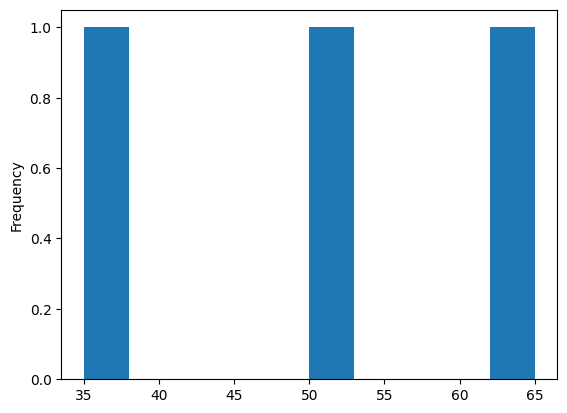

In [28]:
# Here, the dogs variable calls the ['length'] column first. Then the plot method plots the graphs. plot(values in brackets) assign column values for x axis, y axis, and kind of chart. 
#df.plot(
   # x='gdp_per_capita',
   # y='life_expectancy',
   # kind='scatter'
#)

dogs['length'].plot(x ='dog length', y = 'life_expectancy', kind = 'hist')

## 15) Make a horizontal bar graph of the length of the animals, with the animal's name as the label

> **TIP:** It isn't `df['length'].plot()`, because it needs *both* columns. Think about the scatterplot up above.
>
> **TIP:** Which is the `x` axis and which is the `y` axis? You'll notice pandas is kind of weird and wrong.
>
> **TIP:** Make sure you specify the `kind` of graph or else it will be a weird line thing
>
> **TIP:** If you want, you can set a custom size for your plot by sending it something like `figsize=(15,2)`

<Axes: ylabel='name'>

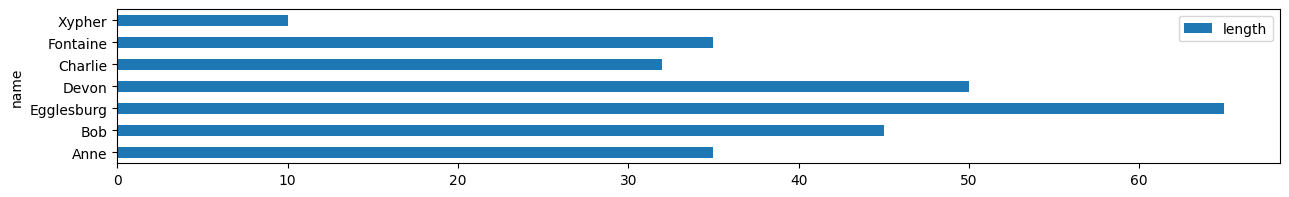

In [29]:
df.plot(x ='name', y='length', kind='barh', figsize=(15,2))

## 16) Make a sorted horizontal bar graph of the cats, with the larger cats on top

> **TIP:** Think in steps, even though it's all on one line - first make sure you can sort it, then try to graph it.

In [30]:
#df.groupby("continent")['life_expectancy'].median().plot(kind='barh')
cats.head()



,animal,name,length,inches
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72
4,cat,Charlie,32,12.60
6,cat,Xypher,10,3.94


In [31]:
#df.sort_values(by="length", ascending = False).head(3)
# refer to previous comment to understand the logic of making charts. 
sorted_cats = cats.sort_values(by='length')
sorted_cats.head()

,animal,name,length,inches
6,cat,Xypher,10,3.94
4,cat,Charlie,32,12.60
0,cat,Anne,35,13.78
1,cat,Bob,45,17.72


<Axes: ylabel='name'>

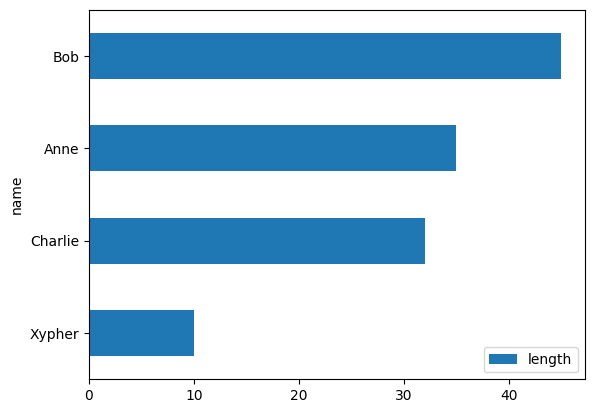

In [32]:
sorted_cats.plot(x= 'name', y='length', kind='barh')


## 17) As a reward (...is it a reward?) for this being the last question: run the following code, then plot the number of dogs vs. the number of cats

When you are done, be sure to tell Dhrumil that FiveThirtyEight has been lonely without him.

> **TIP:** Counting the number of dogs and number of cats does NOT use `.groupby`! That's only for calculations.
>
> **TIP:** You can set a title with `title="Number of animals"`

In [33]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [34]:
#but in pandas there is only one rule: every time you want to count things use value_counts()


In [35]:
cats_count = cats.value_counts()

In [36]:
dogs_count = dogs.value_counts()

<Axes: title={'center': 'Number of animals'}, ylabel='animal'>

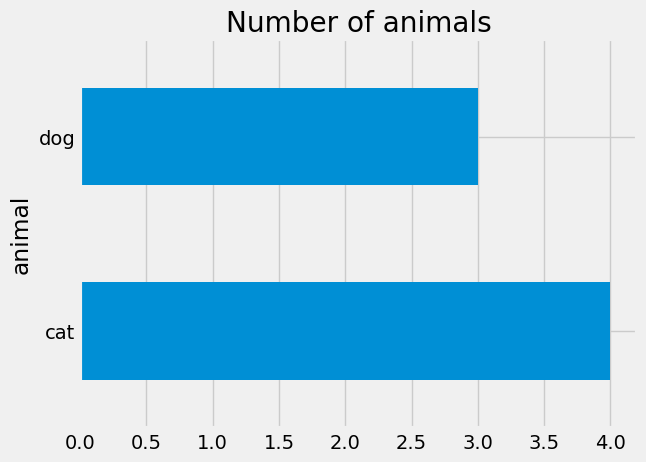

In [38]:
df['animal'].value_counts().plot(title = 'Number of animals', x='count', kind='barh')

## Some Notes about Syntax for myslef.
